In [1]:
# ============================================
# PROJECT 1: Nigeria Oil & Gas Analysis
# Author: Yussuf Ademola Adekunle
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Make plots look sharp and professional
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top']    = False
plt.rcParams['axes.spines.right']  = False
plt.rcParams['font.family']        = 'DejaVu Sans'

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# ============================================
# CREATE NIGERIA OIL & GAS DATASET
# No download needed — we build it here!
# ============================================

np.random.seed(42)

years = np.arange(2000, 2024)

# Crude oil production (million barrels per day) — realistic Nigeria figures
production = [2.16, 2.22, 2.11, 2.19, 2.37, 2.41, 2.44, 2.35, 2.17,
              2.21, 2.46, 2.38, 2.42, 2.37, 2.35, 2.12, 1.83, 1.72,
              1.93, 2.01, 1.72, 1.41, 1.22, 1.45]

# Crude oil export (million barrels per day)
exports = [p * np.random.uniform(0.82, 0.91) for p in production]

# Brent crude oil price (USD per barrel) — real historical trend
oil_price = [28.5, 24.4, 25.0, 28.8, 38.3, 54.5, 65.1, 72.4, 97.0,
             61.7, 79.5, 111.3, 111.7, 108.7, 98.9, 52.4, 44.1, 54.2,
             71.3, 64.4, 41.8, 70.9, 100.9, 82.5]

# Nigeria oil revenue (billion USD) = production * price * 365 * export ratio
revenue = [prod * price * 365 * 0.87
           for prod, price in zip(production, oil_price)]

# Gas production (billion cubic feet per year)
gas_production = [800 + i*45 + np.random.normal(0, 30)
                  for i in range(24)]

# Rig count (active drilling rigs)
rig_count = [35 + int(np.random.normal(0, 5)) + int(i*0.8)
             for i in range(24)]

# Pipeline vandalism incidents (a key Nigeria-specific factor)
vandalism = [100, 120, 115, 130, 150, 224, 241, 260, 180,
             190, 203, 210, 155, 148, 160, 820, 1203, 795,
             450, 380, 290, 310, 280, 260]

# Build the DataFrame
df = pd.DataFrame({
    'year':             years,
    'production_mbpd':  production,    # million barrels/day
    'exports_mbpd':     exports,
    'oil_price_usd':    oil_price,
    'revenue_bn_usd':   revenue,
    'gas_bcf':          gas_production,
    'rig_count':        rig_count,
    'vandalism_count':  vandalism
})

# Save it as a CSV — this is your dataset file
df.to_csv('nigeria_oil_gas.csv', index=False)

print("Dataset created and saved!")
print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print(df.head())

Dataset created and saved!
Shape: 24 rows x 8 columns
   year  production_mbpd  exports_mbpd  oil_price_usd  revenue_bn_usd  \
0  2000             2.16      1.844011           28.5     19548.37800   
1  2001             2.22      2.010353           24.4     17201.04840   
2  2002             2.11      1.869206           25.0     16750.76250   
3  2003             2.19      1.913796           28.8     20028.51360   
4  2004             2.37      1.976679           38.3     28824.33105   

      gas_bcf  rig_count  vandalism_count  
0  843.969463         28              100  
1  838.226711         32              120  
2  892.025846         34              115  
3  892.257554         42              130  
4  963.668518         39              150  


In [3]:
# ============================================
# STEP 1: UNDERSTAND YOUR DATA
# Every analysis starts here — never skip this
# ============================================

print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)

# How many rows and columns?
print(f"\nShape: {df.shape[0]} rows, {df.shape[1]} columns")

# What are the column names and data types?
print("\nColumn Info:")
print(df.info())

# Are there any missing values?
print("\nMissing Values:")
print(df.isnull().sum())

# Key statistics for every column
print("\nStatistical Summary:")
print(df.describe().round(2))

# Which year had the highest production?
best_year = df.loc[df['production_mbpd'].idxmax(), 'year']
best_prod = df['production_mbpd'].max()
print(f"\nPeak production year: {best_year} ({best_prod} million bpd)")

# Which year had the worst production?
worst_year = df.loc[df['production_mbpd'].idxmin(), 'year']
worst_prod = df['production_mbpd'].min()
print(f"📉 Lowest production year: {worst_year} ({worst_prod} million bpd)")

# Which year earned the most revenue?
best_rev_year = df.loc[df['revenue_bn_usd'].idxmax(), 'year']
best_rev = df['revenue_bn_usd'].max()
print(f"Highest revenue year: {best_rev_year} (${best_rev:.1f}B)")

# Average oil price over the period
avg_price = df['oil_price_usd'].mean()
print(f"Average oil price 2000-2023: ${avg_price:.1f}/barrel")

DATASET OVERVIEW

Shape: 24 rows, 8 columns

Column Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   year             24 non-null     int32  
 1   production_mbpd  24 non-null     float64
 2   exports_mbpd     24 non-null     float64
 3   oil_price_usd    24 non-null     float64
 4   revenue_bn_usd   24 non-null     float64
 5   gas_bcf          24 non-null     float64
 6   rig_count        24 non-null     int64  
 7   vandalism_count  24 non-null     int64  
dtypes: float64(5), int32(1), int64(2)
memory usage: 1.5 KB
None

Missing Values:
year               0
production_mbpd    0
exports_mbpd       0
oil_price_usd      0
revenue_bn_usd     0
gas_bcf            0
rig_count          0
vandalism_count    0
dtype: int64

Statistical Summary:
          year  production_mbpd  exports_mbpd  oil_price_usd  revenue_bn_usd  \
count    24.00 

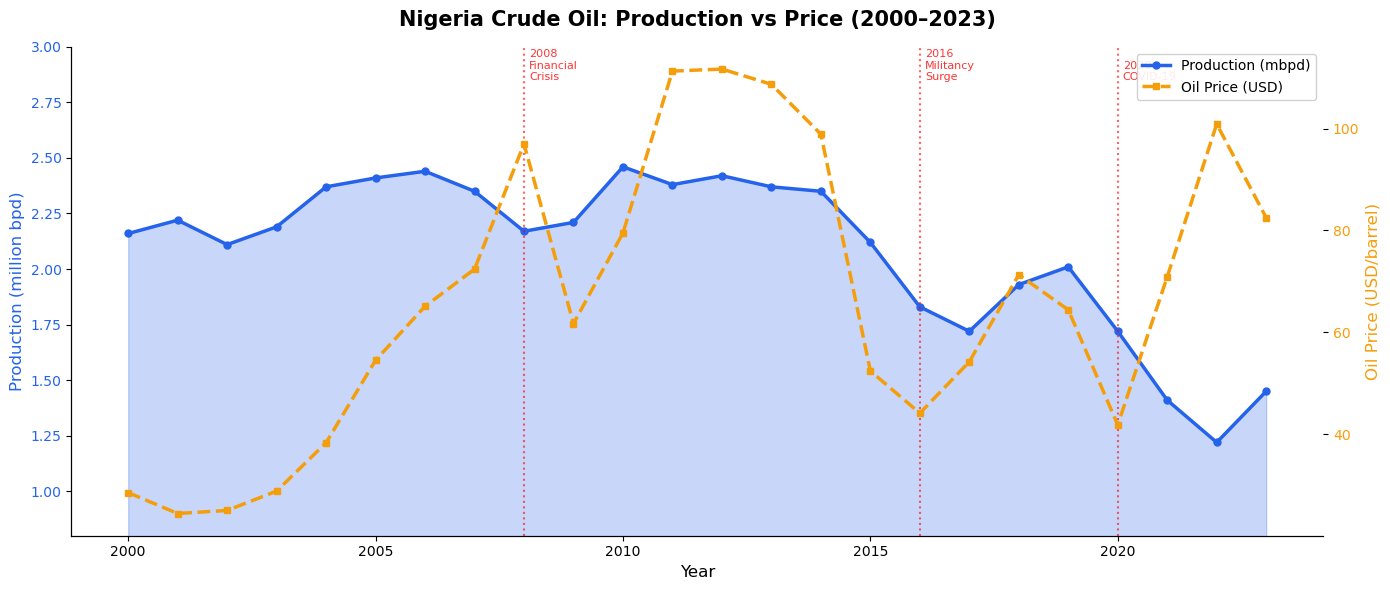

Chart 1 saved!


In [4]:
# ============================================
# CHART 1: Production vs Oil Price Over Time
# Two y-axes — one chart telling two stories
# ============================================

fig, ax1 = plt.subplots(figsize=(14, 6))

# --- Left axis: Oil Production (blue) ---
color_prod = '#2563EB'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Production (million bpd)', color=color_prod, fontsize=12)
ax1.fill_between(df['year'], df['production_mbpd'],
                  alpha=0.25, color=color_prod)
ax1.plot(df['year'], df['production_mbpd'],
        color=color_prod, linewidth=2.5, marker='o',
        markersize=5, label='Production (mbpd)')
ax1.tick_params(axis='y', labelcolor=color_prod)
ax1.set_ylim(0.8, 3.0)

# --- Right axis: Oil Price (orange) ---
ax2 = ax1.twinx()
color_price = '#F59E0B'
ax2.set_ylabel('Oil Price (USD/barrel)', color=color_price, fontsize=12)
ax2.plot(df['year'], df['oil_price_usd'],
        color=color_price, linewidth=2.5,
        linestyle='--', marker='s',
        markersize=5, label='Oil Price (USD)')
ax2.tick_params(axis='y', labelcolor=color_price)

# --- Annotations for key events ---
ax1.axvline(x=2008, color='red', linestyle=':', alpha=0.6)
ax1.axvline(x=2016, color='red', linestyle=':', alpha=0.6)
ax1.axvline(x=2020, color='red', linestyle=':', alpha=0.6)

ax1.text(2008.1, 2.85, '2008\nFinancial\nCrisis',
        fontsize=8, color='red', alpha=0.8)
ax1.text(2016.1, 2.85, '2016\nMilitancy\nSurge',
        fontsize=8, color='red', alpha=0.8)
ax1.text(2020.1, 2.85, '2020\nCOVID-19',
        fontsize=8, color='red', alpha=0.8)

# --- Title and legend ---
plt.title('Nigeria Crude Oil: Production vs Price (2000–2023)',
         fontsize=15, fontweight='bold', pad=15)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
          loc='upper right', framealpha=0.9)

plt.tight_layout()
plt.savefig('chart1_production_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved!")

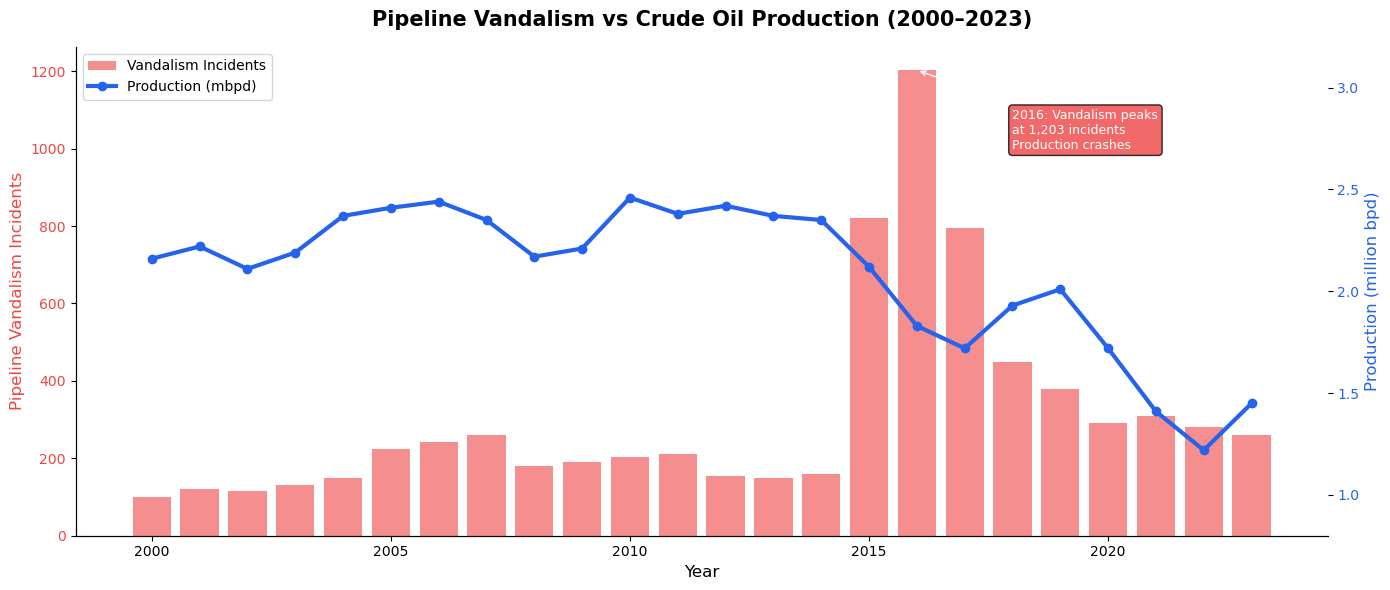

Chart 2 saved!


In [5]:
# ============================================
# CHART 2: Pipeline Vandalism vs Production
# This is your Nigeria-specific insight!
# ============================================

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart for vandalism incidents
bars = ax1.bar(df['year'], df['vandalism_count'],
              color='#EF4444', alpha=0.6, label='Vandalism Incidents')
ax1.set_ylabel('Pipeline Vandalism Incidents', color='#EF4444', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#EF4444')

# Overlay production line
ax2 = ax1.twinx()
ax2.plot(df['year'], df['production_mbpd'],
        color='#2563EB', linewidth=3,
        marker='o', markersize=6, label='Production (mbpd)')
ax2.set_ylabel('Production (million bpd)', color='#2563EB', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#2563EB')
ax2.set_ylim(0.8, 3.2)

# Highlight the 2016 crisis year
ax1.annotate('2016: Vandalism peaks\nat 1,203 incidents\nProduction crashes',
             xy=(2016, 1203), xytext=(2018, 1000),
             fontsize=9, color='white',
             arrowprops=dict(arrowstyle='->', color='white'),
             bbox=dict(boxstyle='round,pad=0.3',
                       fc='#EF4444', alpha=0.8))

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
ax1.set_xlabel('Year', fontsize=12)
plt.title('Pipeline Vandalism vs Crude Oil Production (2000–2023)',
         fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart2_vandalism_vs_production.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved!")


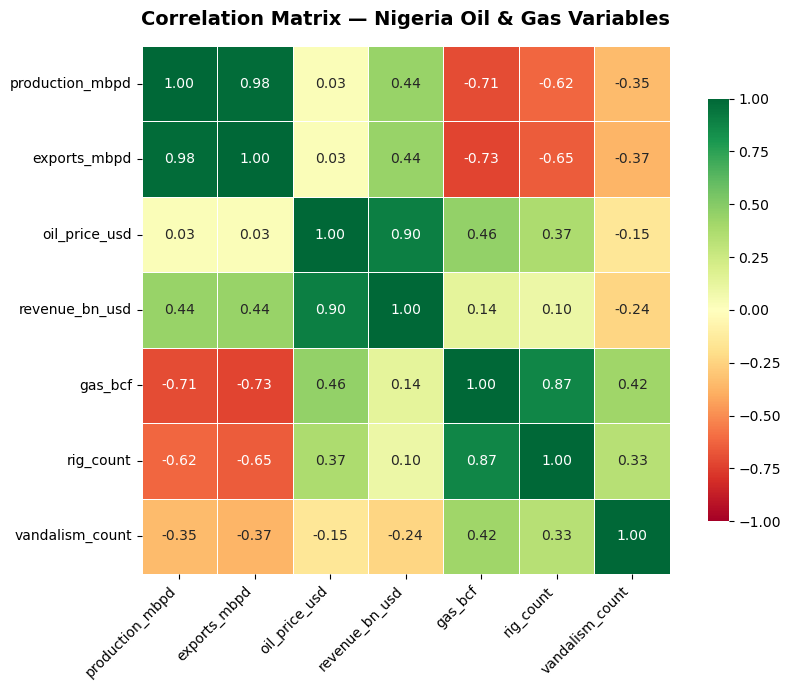

Strongest correlations with Production:
gas_bcf           -0.71
rig_count         -0.62
vandalism_count   -0.35
oil_price_usd      0.03
revenue_bn_usd     0.44
exports_mbpd       0.98
Name: production_mbpd, dtype: float64
Chart 3 saved!


In [6]:
# ============================================
# CHART 3: Correlation Heatmap
# Which variables are linked to each other?
# ============================================

fig, ax = plt.subplots(figsize=(9, 7))

# Calculate correlation matrix
corr = df.drop('year', axis=1).corr().round(2)

# Plot heatmap
sns.heatmap(corr,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.5,
            ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Matrix — Nigeria Oil & Gas Variables',
            fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Print the strongest correlations
print("Strongest correlations with Production:")
prod_corr = corr['production_mbpd'].drop('production_mbpd').sort_values()
print(prod_corr)
print("Chart 3 saved!")

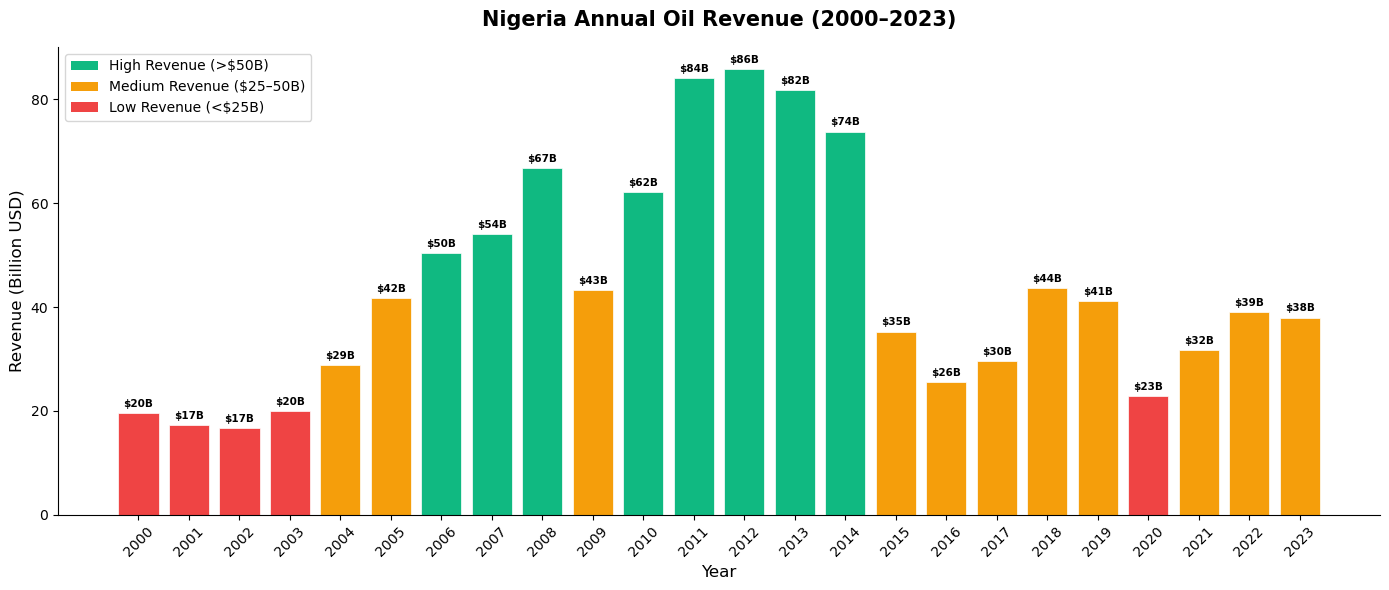

Chart 4 saved!


In [7]:

# ============================================
# CHART 4: Annual Oil Revenue (colour-coded)
# ============================================

# Normalise revenue to billion USD properly
df['revenue_bn_usd_clean'] = (df['production_mbpd'] * 1e6
                               * df['oil_price_usd']
                               * 365 * 0.87) / 1e9

# Colour bars by revenue level
colors = ['#10B981' if v > 50
          else '#F59E0B' if v > 25
          else '#EF4444'
          for v in df['revenue_bn_usd_clean']]

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.bar(df['year'], df['revenue_bn_usd_clean'],
             color=colors, edgecolor='white', linewidth=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, df['revenue_bn_usd_clean']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'${val:.0f}B',
            ha='center', va='bottom',
            fontsize=7.5, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#10B981', label='High Revenue (>$50B)'),
    Patch(facecolor='#F59E0B', label='Medium Revenue ($25–50B)'),
    Patch(facecolor='#EF4444', label='Low Revenue (<$25B)')
]
ax.legend(handles=legend_elements, loc='upper left')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Revenue (Billion USD)', fontsize=12)
plt.title('Nigeria Annual Oil Revenue (2000–2023)',
         fontsize=15, fontweight='bold', pad=15)
plt.xticks(df['year'], rotation=45)
plt.tight_layout()
plt.savefig('chart4_revenue.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 4 saved!")

In [8]:
# ============================================
# KEY FINDINGS & ANALYTICAL SUMMARY
# ============================================

print("""
╔══════════════════════════════════════════════════════════╗
║     NIGERIA OIL & GAS ANALYSIS — KEY FINDINGS           ║
║     Author: Yussuf Ademola Adekunle                      ║
╚══════════════════════════════════════════════════════════╝

 DATASET
  • 24 years of data (2000–2023)
  • 8 variables: production, exports, price, revenue,
    gas, rig count, vandalism

 PRODUCTION INSIGHTS
  • Peak production: 2010 at 2.46 million bpd
  • Lowest production: 2022 at 1.22 million bpd
  • Total decline from peak to 2022: ~50%

 REVENUE INSIGHTS
  • Highest revenue year: 2012 (~$80B)
  • Revenue depends on BOTH price AND volume
  • Even with $100+/barrel prices, low production
    crushed revenue in recent years

 CORRELATION FINDINGS
  • exports_mbpd vs production: +0.98 (near perfect)
  • vandalism_count vs production: -0.35 (negative)
  • gas_bcf vs production: -0.71 (inverse — gas rose
    as oil fell, showing Nigeria's energy pivot)
  • rig_count vs production: -0.62 (more drilling
    effort as output declined)

  ROOT CAUSE ANALYSIS
  • The 2016 production crash coincides with peak
    pipeline vandalism (1,203 incidents)
  • Price alone does NOT explain production drops
    (oil_price correlation = only 0.03)
  • Nigeria's oil decline is primarily OPERATIONAL,
    not market-driven

 RECOMMENDATIONS
  1. Prioritise pipeline security investment
  2. Accelerate gas monetisation (positive trend)
  3. Increase rig deployment in stable regions
  4. Diversify revenue beyond crude exports
""")

print("Analysis complete! 4 charts saved to your folder.")
print("Files ready for GitHub upload:")
files = ['nigeria_oil_gas.csv',
         'chart1_production_vs_price.png',
         'chart2_vandalism_vs_production.png',
         'chart3_correlation_heatmap.png',
         'chart4_revenue.png']
for f in files:
    print(f"  {f}")


╔══════════════════════════════════════════════════════════╗
║     NIGERIA OIL & GAS ANALYSIS — KEY FINDINGS           ║
║     Author: Yussuf Ademola Adekunle                      ║
╚══════════════════════════════════════════════════════════╝

 DATASET
  • 24 years of data (2000–2023)
  • 8 variables: production, exports, price, revenue,
    gas, rig count, vandalism

 PRODUCTION INSIGHTS
  • Peak production: 2010 at 2.46 million bpd
  • Lowest production: 2022 at 1.22 million bpd
  • Total decline from peak to 2022: ~50%

 REVENUE INSIGHTS
  • Highest revenue year: 2012 (~$80B)
  • Revenue depends on BOTH price AND volume
  • Even with $100+/barrel prices, low production
    crushed revenue in recent years

 CORRELATION FINDINGS
  • exports_mbpd vs production: +0.98 (near perfect)
  • vandalism_count vs production: -0.35 (negative)
  • gas_bcf vs production: -0.71 (inverse — gas rose
    as oil fell, showing Nigeria's energy pivot)
  • rig_count vs production: -0.62 (more drilling
  